# PID Control Simulation for Balancing Beam Drone on a Pivot

In [39]:
import random
import matplotlib.pyplot as plt

In [174]:
# Defination the physical characteristic of the drone on a pivot
MASS = 0.5 # 500 grams
LENGTH = 3.0 # meters
ARMS_LENGTH = int(LENGTH / 2) # The length of the drone to the pivot

# Calculation of the moment of inertia of a think rod on a center axis (suspended on a pivot) = I = 1/12 (ML^2)
INERTIA = (1.0 / 12.0) * MASS * (LENGTH ** 2)
BASE_THROTTLE = 5.0 # Base throttle of the drone's propellers to maintain hover state on the pivot

# PID Constants definations, set to zeros initially and adjust or tune later
KP,KI,KD=0.2,0.03,0.5 

In [175]:
# State of the drone on a pivot, initial simulation configurations

# Definition for time, duration and steps for the PID control loop time
dt = 0.01
total_time = 50.0
total_steps = int(total_time / dt)

# Initial state of the drone on a pivot
current_angle = -25.0 # Initial angle of the drone on the pivot
angular_velocity = 0.0 # Initial angular velocity of the drone on the pivot
angular_acceleration = 0.0 # Initial angular acceleration of the drone on the pivot

target_angle = 0.0 # Target angle of the drone on the pivot

In [176]:
integral_error = 0.0
last_error = 0.0

time_history = []
target_history = []
angle_history = []

for steps in range(total_steps):
    current_time = steps * dt

    sensor_angle = current_angle + random.gauss(0, 0.01) # Simulate getting the current angle of the drone from an onboard sensor
    # Adding random noise to simulate vibrations and noise of a real drone

    error = target_angle - sensor_angle
    # Current error the drone is facing towards achieving target at this step of the control loop, or at this instance\

    integral_error += error * dt
    integral_error = max(min(integral_error, 10.0), -10.0) # Capping the acumulated intergral between postive and negative 10

    derivative_error = (error - last_error) / dt # The derivative error as the predicted error boundary or whatever
    last_error = error

    # PID Output 
    pid_output = (KP * error) + (KI * integral_error) + (KD * derivative_error)

    # Motor mixing
    thrust_left = BASE_THROTTLE - pid_output
    thrust_right = BASE_THROTTLE + pid_output
    # Adjusting the thrust produced by the two propellers accordingly by adjusting there throttle

    # Capping the max and min thrust of the two proppeller to avoid over throttling and negative throttling.
    # Which a physical propeller can not do and will cause stuid errors here in this simulations
    thrust_left = max(min(thrust_left, 15.0), 0.0)
    thrust_right = max(min(thrust_right, 15.0), 0.0)

    net_torque = (thrust_right - thrust_left) * ARMS_LENGTH

    angular_acceleration = net_torque / INERTIA
    angular_velocity += angular_acceleration * dt
    current_angle += angular_velocity * dt

    time_history.append(current_time)
    target_history.append(target_angle)
    angle_history.append(current_angle)
    

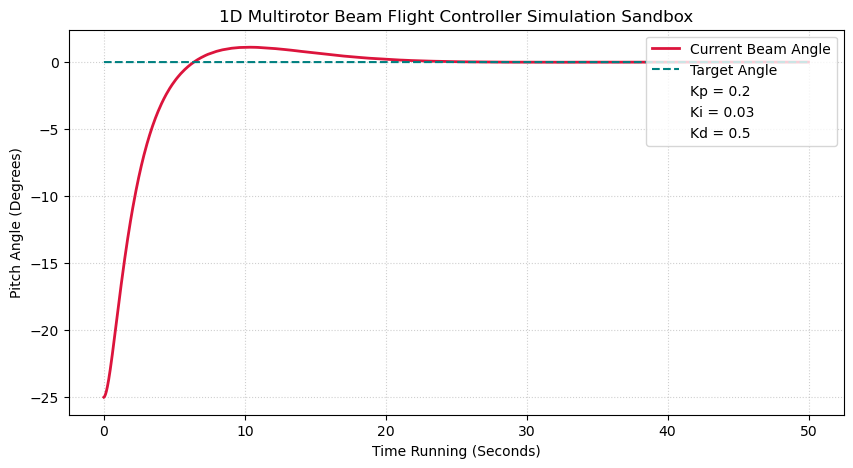

In [179]:
plt.figure(figsize=(10, 5))
plt.plot(time_history, angle_history, label="Current Beam Angle", color='crimson', linewidth=2)
plt.plot(time_history, target_history, label="Target Angle", color='teal', linestyle='--', linewidth=1.5)

plt.plot([], [], ' ', label=f"Kp = {KP}")
plt.plot([], [], ' ', label=f"Ki = {KI}")
plt.plot([], [], ' ', label=f"Kd = {KD}")

plt.title("1D Multirotor Beam Flight Controller Simulation Sandbox", fontsize=12)
plt.xlabel("Time Running (Seconds)", fontsize=10)
plt.ylabel("Pitch Angle (Degrees)", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="upper right")
plt.show()